In [21]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [18]:
file_path_3C = '/Users/zkf/Desktop/test/file/女性特有变量分析.csv' 
file_path_3D = '/Users/zkf/Desktop/test/file/生活方式关联分析结果.csv'
file_path_3E = '/Users/zkf/Desktop/test/file/Disease_Cox_Detailed_Final_Results.csv'
file_path_3F = "/Users/zkf/Desktop/test/file/Organ_Gaps_Cox_Sex_Dimorphism_Corrected_output.csv"
file_path_3G = '/Users/zkf/Desktop/test/file/Mortality_Five_Systems_Detailed_Results.csv'

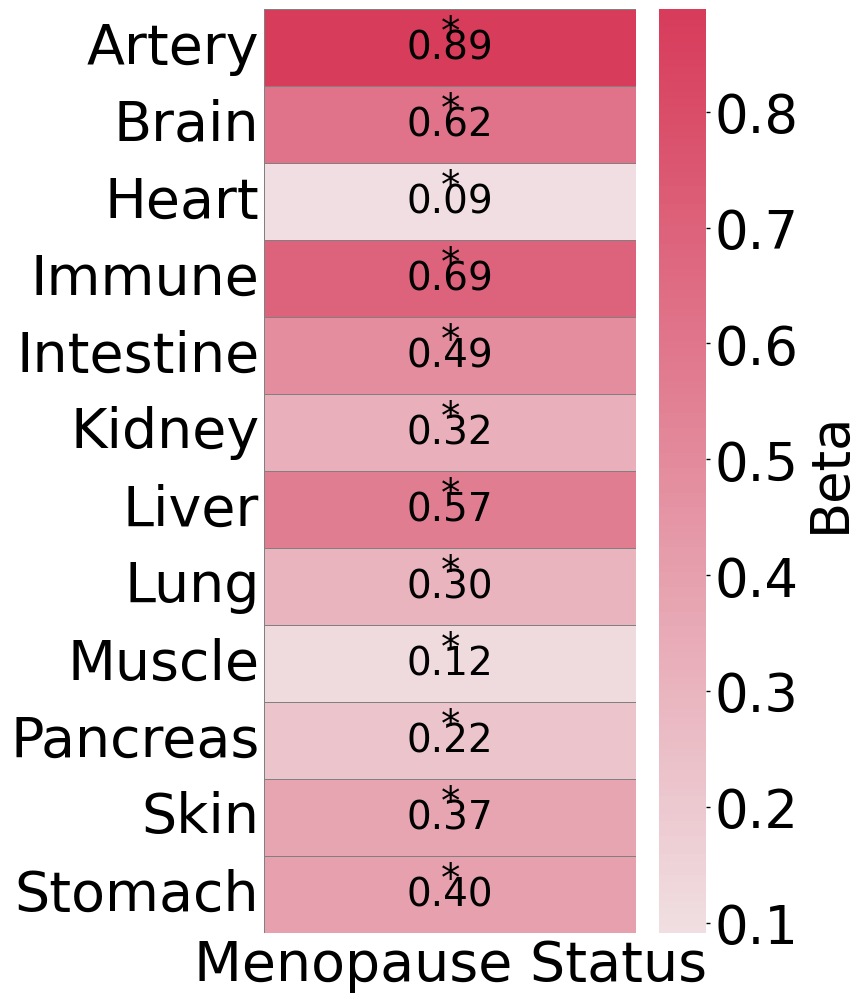

In [6]:
# Fig.3C
df = pd.read_csv(file_path_3C)


df_heatmap = df[['Organ', 'Factor', 'Beta', 'P_Adj']]


df_heatmap_menopause = df_heatmap[df_heatmap['Factor'] == 'Menopause Status']


heatmap_data = df_heatmap_menopause.pivot_table(index='Organ', columns='Factor', values='Beta')


custom_cmap = sns.diverging_palette(255, 5, as_cmap=True)


fig, ax = plt.subplots(figsize=(6, 12))  

sns.heatmap(
    heatmap_data,
    cmap=custom_cmap,
    annot=True,
    fmt=".2f",
    center=0,  
    
    annot_kws={
        "size": 28,  
        "weight": "normal",  
        "color": "black",  
        "va": "center",
        "ha": "center"
    },
    linewidths=0.5,
    linecolor='gray'
)


cbar = ax.collections[0].colorbar

cbar.set_label(label='Beta', fontsize=38)

cbar.ax.tick_params(labelsize=38, width=1.0, length=3)


for i in range(len(df_heatmap_menopause)):
    organ = df_heatmap_menopause.iloc[i]['Organ']
    factor = df_heatmap_menopause.iloc[i]['Factor']
    p_adj = df_heatmap_menopause.iloc[i]['P_Adj']
    if p_adj < 0.05:  
        
        ax = plt.gca()
        x = heatmap_data.columns.get_loc(factor)
        y = heatmap_data.index.get_loc(organ)
        ax.text(x + 0.5, y + 0.3, '*', ha='center', va='center', color='black', fontsize=28)


ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=40)
ax.set_xticklabels(ax.get_xticklabels(), rotation=0, fontsize=40)

ax.tick_params(axis='y', which='both', length=0)
ax.tick_params(axis='x', which='both', length=0)


plt.ylabel('', fontsize=28)
plt.xlabel('', fontsize=28)

plt.show()

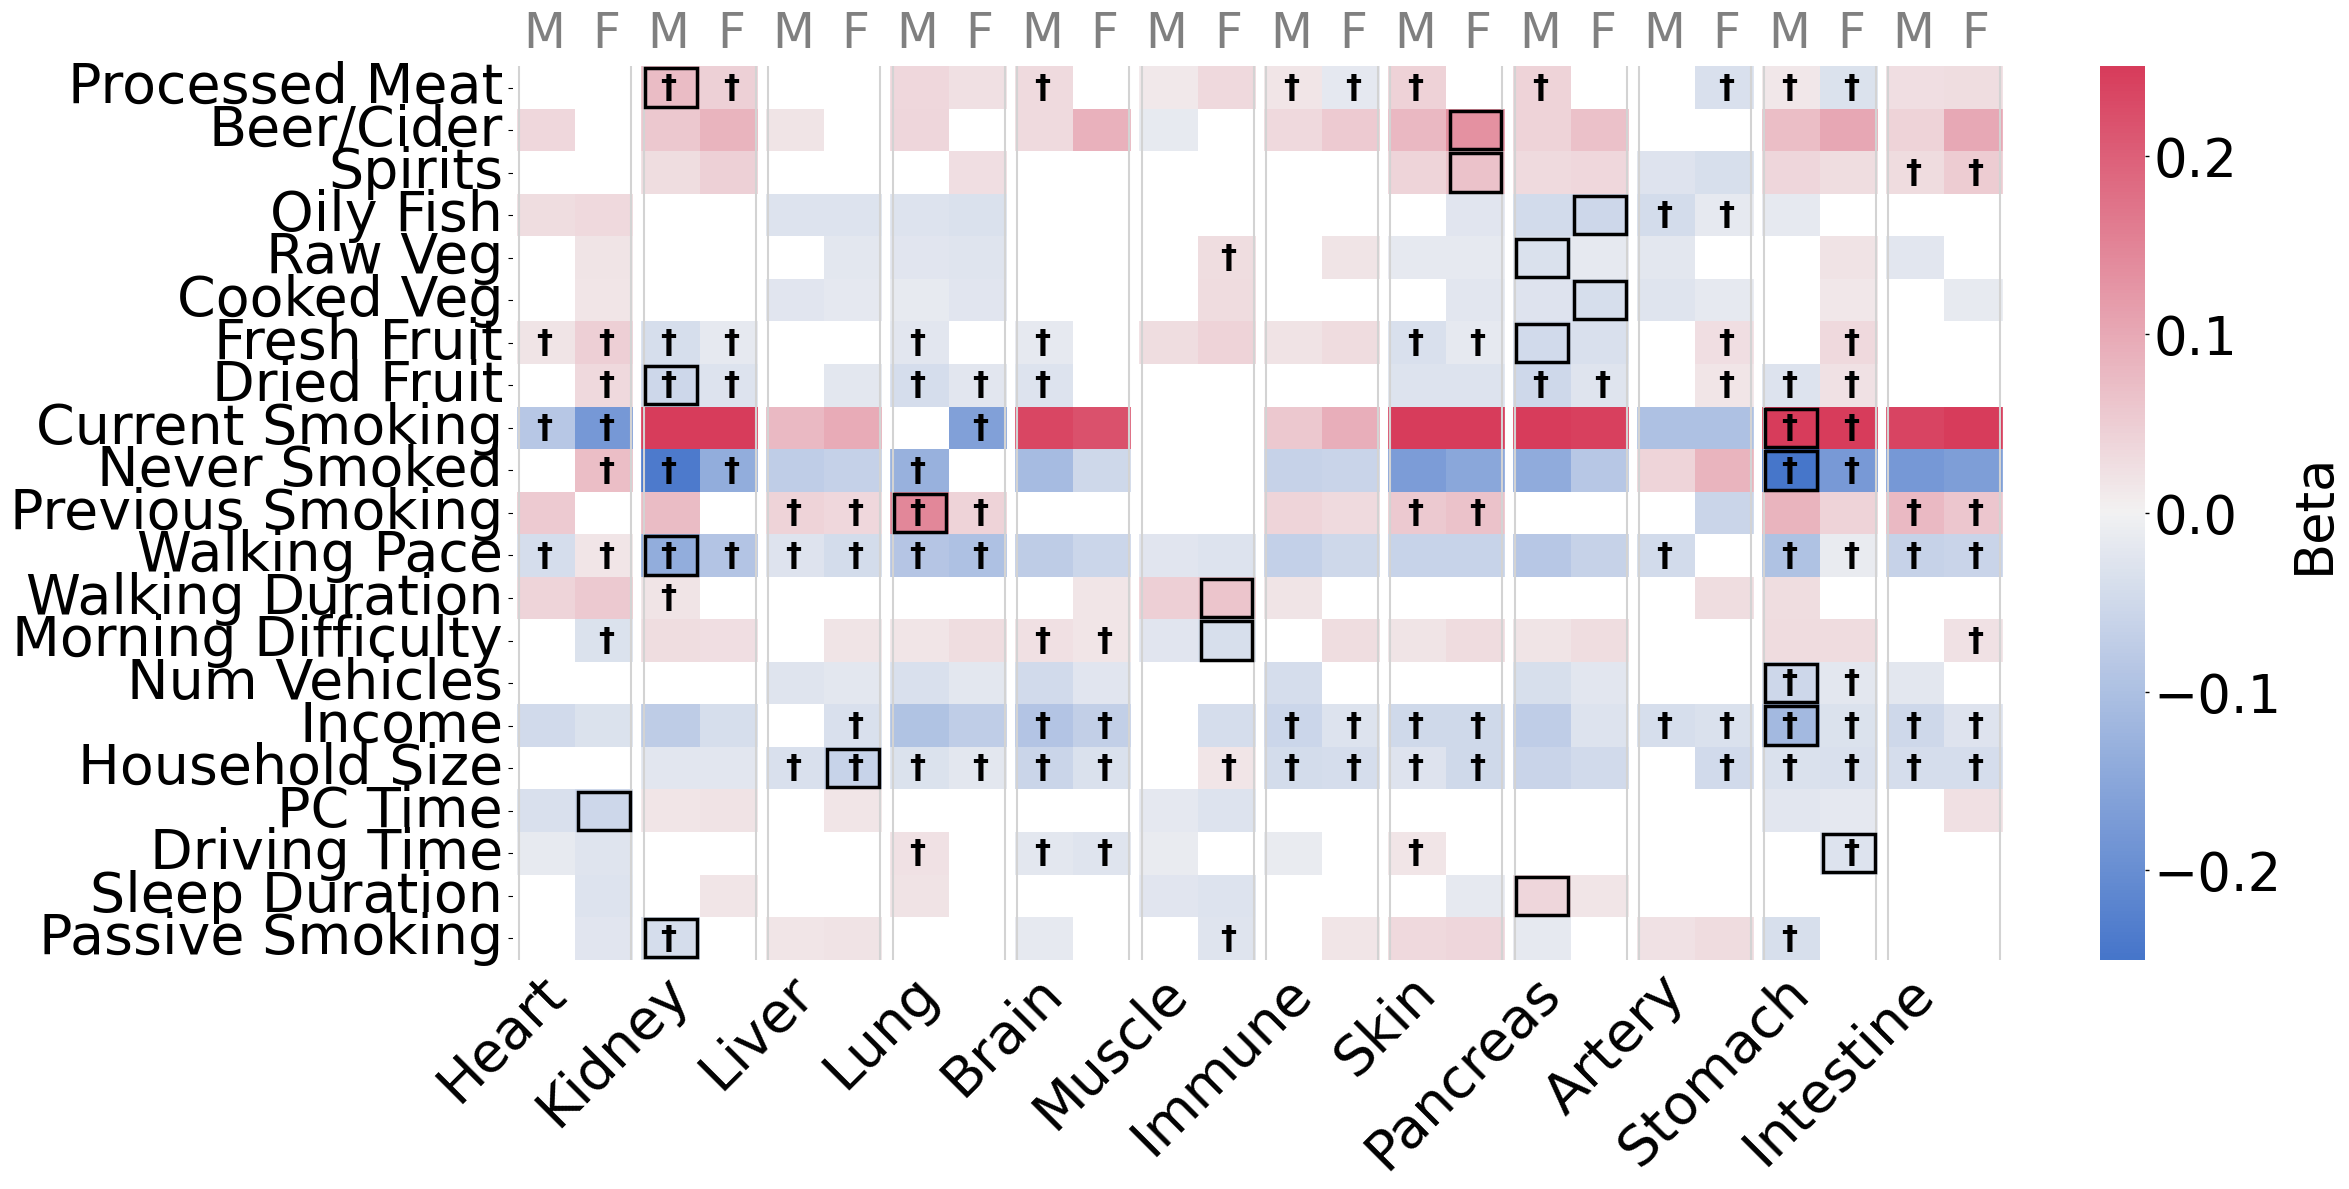

In [12]:
# Fig.3D





ORGAN_LABELS = [
    'Heart', 'Kidney', 'Liver', 'Lung', 'Brain', 'Muscle',
    'Immune', 'Skin', 'Pancreas', 'Artery', 'Stomach', 'Intestine'
]


COMBINED_LIFESTYLE_VARS=[
    'Processed Meat','Beer/Cider','Spirits','Oily Fish','Raw Veg','Cooked Veg','Fresh Fruit','Dried Fruit',
    'Current Smoking','Never Smoked','Previous Smoking',
    'Walking Pace','Walking Duration','Morning Difficulty',
    'Num Vehicles','Income', 'Household Size',
    'PC Time','Driving Time','Sleep Duration',
    'Passive Smoking'

]

def plot_combined_lifestyle_heatmap():
   

    df = pd.read_csv(file_path_3D)

    
    df['Beta_Male_Plot'] = df.apply(lambda row: row['Beta_Male'] if row['P_Male_Adj'] < 0.05 else 0, axis=1)
    df['Beta_Female_Plot'] = df.apply(lambda row: row['Beta_Female'] if row['P_Female_Adj'] < 0.05 else 0, axis=1)
    df['Mark_Interaction'] = df['P_Interaction_Adj'] < 0.05

    df_indexed = df.set_index(['Label', 'Organ'])
    custom_cmap = sns.diverging_palette(255, 5, as_cmap=True)

    
    current_vars = [v for v in COMBINED_LIFESTYLE_VARS if v in df['Label'].unique()]

    mat_beta, mat_text = [], []
    highlight_coords = []

    for r_idx, var_label in enumerate(current_vars):
        row_beta, row_text = [], []
        row_values_for_max = []

        current_col_idx = 0
        for organ in ORGAN_LABELS:
            try:
                record = df_indexed.loc[(var_label, organ)]

                # Male 数据列
                val_m = record['Beta_Male_Plot']
                row_beta.append(val_m)
                row_text.append("†" if record['Mark_Interaction'] else "")
                if val_m != 0: row_values_for_max.append((abs(val_m), current_col_idx))
                current_col_idx += 1

                # Female 数据列
                val_f = record['Beta_Female_Plot']
                row_beta.append(val_f)
                row_text.append("†" if record['Mark_Interaction'] else "")
                if val_f != 0: row_values_for_max.append((abs(val_f), current_col_idx))
                current_col_idx += 1
            except KeyError:
                row_beta.extend([0, 0])
                row_text.extend(["", ""])
                current_col_idx += 2

        mat_beta.append(row_beta)
        mat_text.append(row_text)

        
        if row_values_for_max:
            row_values_for_max.sort(key=lambda x: x[0], reverse=True)
            max_val, max_col_idx = row_values_for_max[0]
            if max_val > 0:
                highlight_coords.append((r_idx, max_col_idx))

    df_beta = pd.DataFrame(mat_beta, index=current_vars)
    df_text = pd.DataFrame(mat_text, index=current_vars)

    
    h = max(6, len(current_vars) * 0.38)
    fig, ax = plt.subplots(figsize=(24, 12))

    


    max_val = df_beta.abs().max().max()
    
    mask = (df_beta == 0)

    
    sns.heatmap(df_beta,
                cmap=custom_cmap,
                center=0,
                
                vmin=-0.25, vmax=0.25,
                mask=mask,
                annot=df_text, fmt='',
                annot_kws={'size': 23, 'weight': 'bold', 'color': 'black'},
                linewidths=0,
               
                xticklabels=False,
                ax=ax)

    
    cbar = ax.collections[0].colorbar
    
    cbar.set_label(label='Beta', fontsize=38)
    
    cbar.ax.tick_params(labelsize=38, width=1.0, length=3)

    
    n_cols = df_beta.shape[1]
    for i in range(0, n_cols + 1, 2):
        ax.axvline(i, color='white', lw=6, clip_on=True, zorder=5)
        if i > 0:
            ax.axvline(i - 0.1, color='lightgrey', lw=1.5, clip_on=True, zorder=5)
        if i < n_cols:
            ax.axvline(i + 0.1, color='lightgrey', lw=1.5, clip_on=True, zorder=5)
            # 标注 M 和 F
            ax.text(i + 0.5, 1.01, 'M', ha='center', va='bottom', transform=ax.get_xaxis_transform(), fontsize=35,
                    color='gray')
            ax.text(i + 1.5, 1.01, 'F', ha='center', va='bottom', transform=ax.get_xaxis_transform(), fontsize=35,
                    color='gray')

    
    pad_y, pad_x_inner, pad_x_outer = 0.05, 0.05, 0.12
    for r, c in highlight_coords:
        is_male_col = (c % 2 == 0)
        x_start = c + (pad_x_outer if is_male_col else pad_x_inner)
        width = 1 - (pad_x_outer + pad_x_inner)

        rect = patches.Rectangle(
            (x_start, r + pad_y), width, 1 - 2 * pad_y,
            linewidth=2.5, edgecolor='black', facecolor='none', clip_on=True, zorder=100
        )
        ax.add_patch(rect)

    
    ax.set_yticklabels(ax.get_yticklabels(), rotation=0, fontsize=40)
    bottom_ticks = np.arange(len(ORGAN_LABELS)) * 2 + 1
    ax.set_xticks(bottom_ticks)
    ax.set_xticklabels(ORGAN_LABELS, rotation=45, ha='right', fontsize=40)
    ax.tick_params(axis='x', length=0)



    for spine in ax.spines.values():
        spine.set_visible(False)

    
    plt.ylabel("")
    plt.tight_layout()

  
    plt.show()



plot_combined_lifestyle_heatmap()

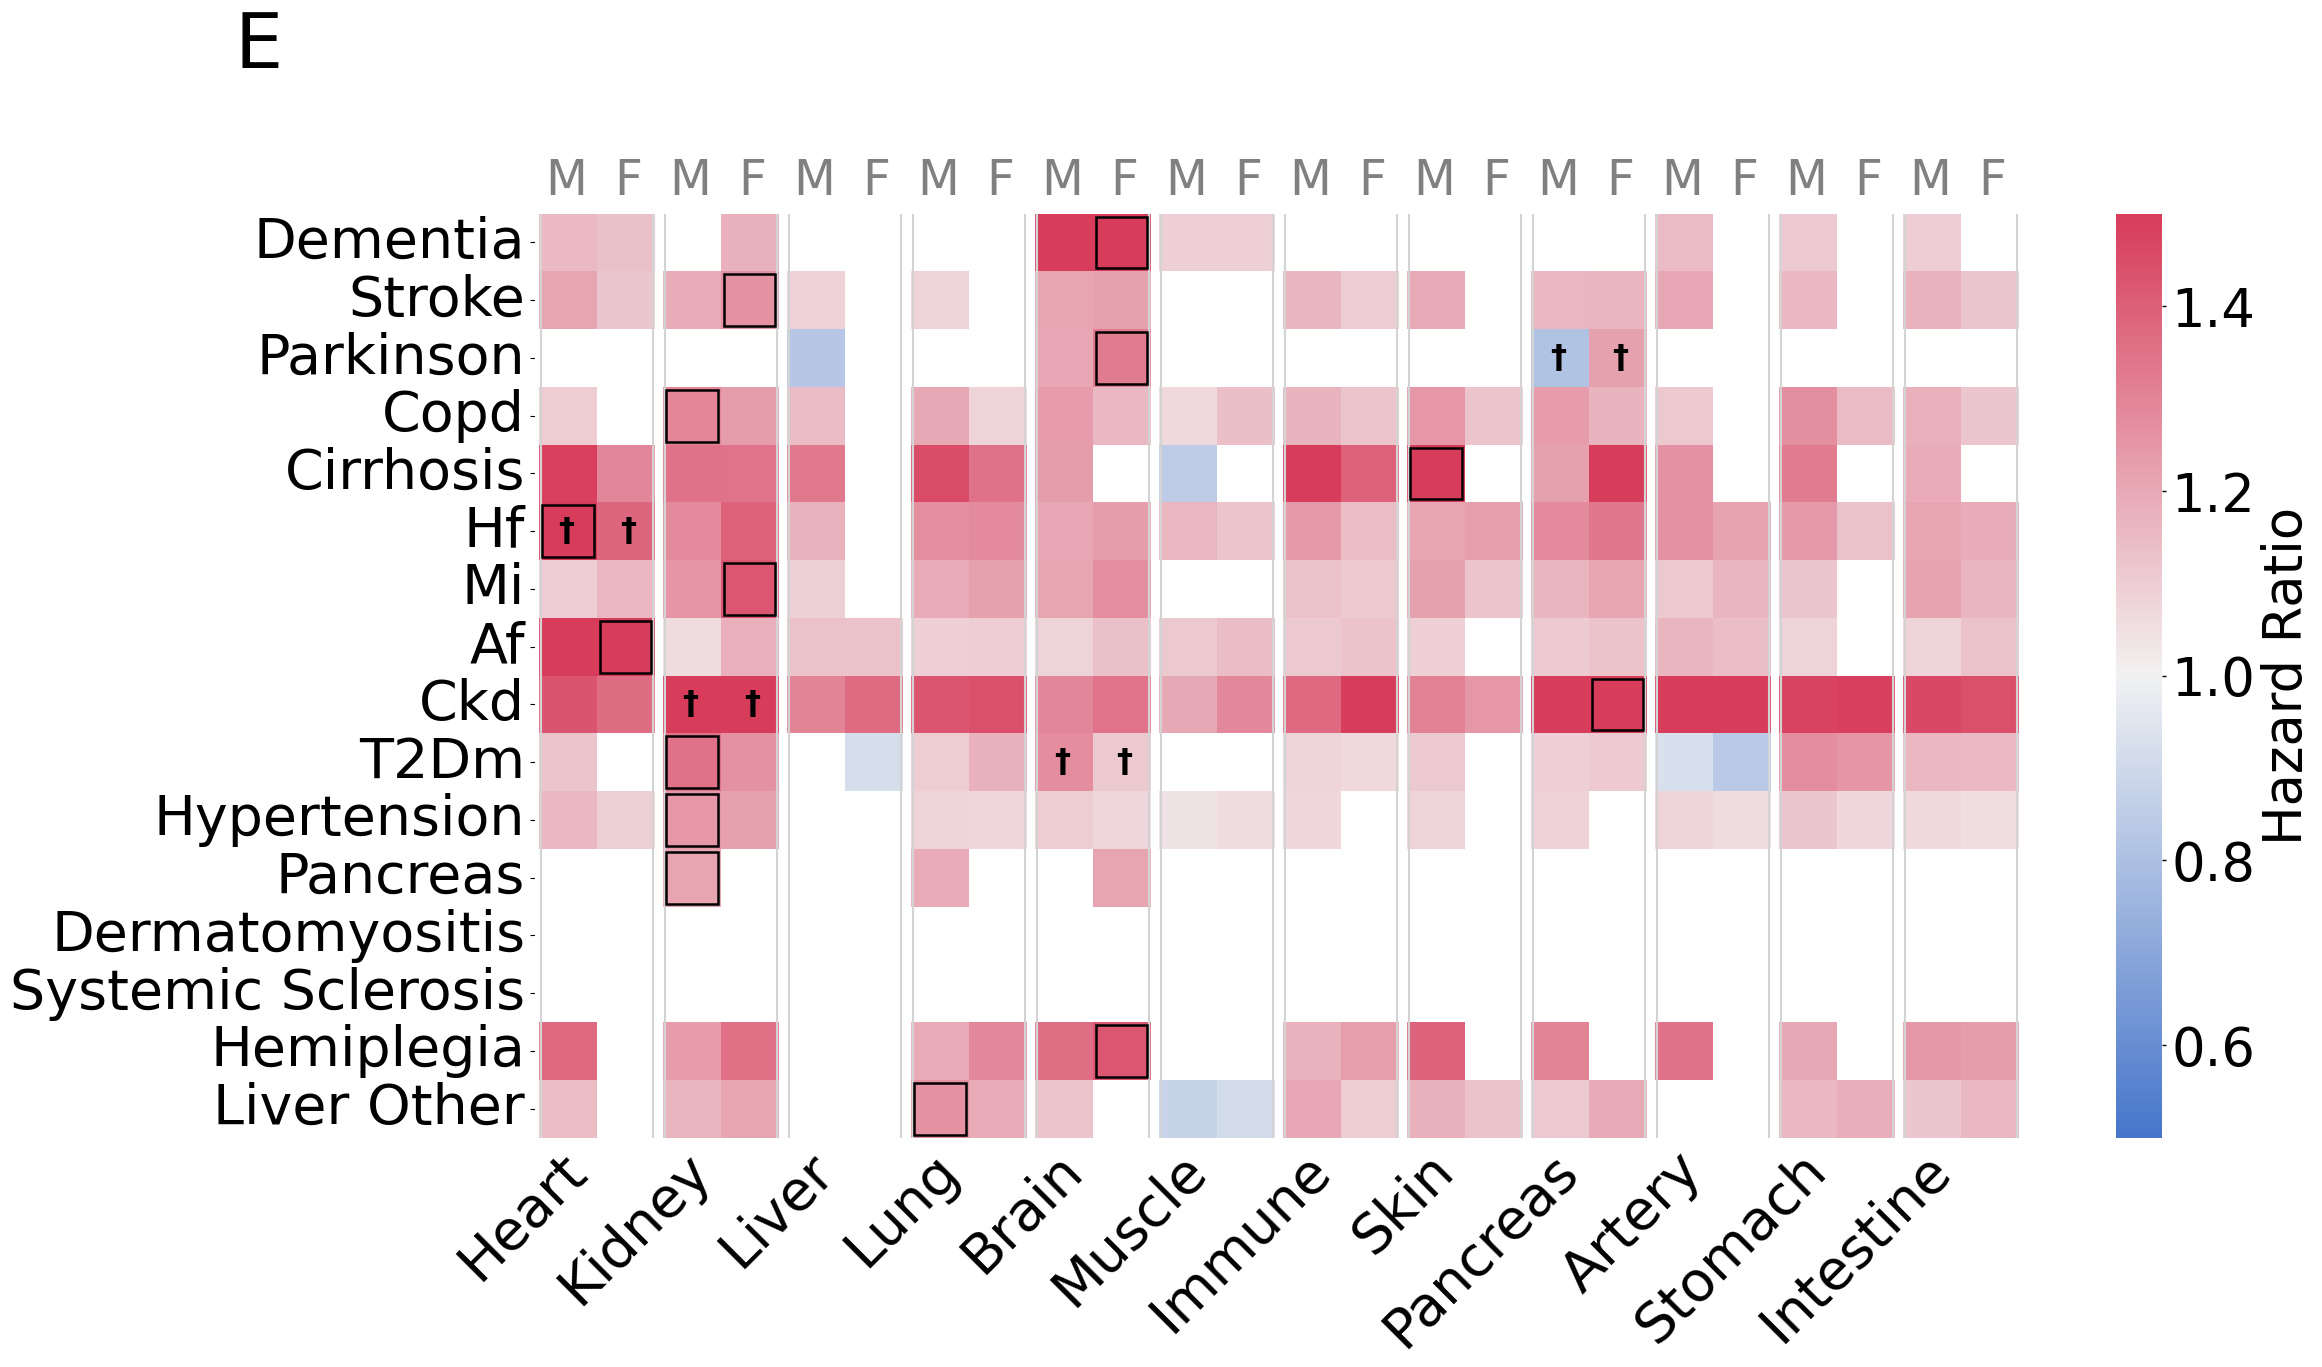

In [11]:
# Fig.3E

custom_cmap = sns.diverging_palette(255, 5, as_cmap=True)

ORGAN_ORDER = [
    "Heart_Z_Gap", "Kidney_Z_Gap", "Liver_Z_Gap", "Lung_Z_Gap",
    "Brain_Z_Gap", "Muscle_Z_Gap", "Immune_Z_Gap", "Skin_Z_Gap",
    "Pancreas_Z_Gap", "Artery_Z_Gap", "Stomach_Z_Gap", "Intestine_Z_Gap"
]

DISEASE_ORDER = [
    'date_dementia', 'date_stroke', 'date_parkinson', 'date_copd',
    'date_cirrhosis', 'date_hf', 'date_mi', 'date_af',
    'date_ckd', 'date_t2dm', 'date_hypertension', 'date_pancreas',
    'date_dermatomyositis', 'date_systemic_sclerosis', 'date_hemiplegia', 'date_liver_other'
]

def clean_label(text):
    return text.replace('date_', '').replace('_Z_Gap', '').replace('_', ' ').title()

def prepare_matrices(df):
    df_male = df[df['Group'] == 'Male'].set_index(['Disease', 'Organ'])
    df_female = df[df['Group'] == 'Female'].set_index(['Disease', 'Organ'])
    df_total = df[df['Group'] == 'Total'].set_index(['Disease', 'Organ'])

    hr_male = df_male['HR'].unstack('Organ').reindex(index=DISEASE_ORDER, columns=ORGAN_ORDER)
    hr_female = df_female['HR'].unstack('Organ').reindex(index=DISEASE_ORDER, columns=ORGAN_ORDER)

    mask_male = (df_male['P_val_adj'].unstack('Organ').reindex(index=DISEASE_ORDER, columns=ORGAN_ORDER) >= 0.05)
    mask_female = (df_female['P_val_adj'].unstack('Organ').reindex(index=DISEASE_ORDER, columns=ORGAN_ORDER) >= 0.05)

    p_inter = df_total['P_interaction_fdr'].unstack('Organ').reindex(index=DISEASE_ORDER, columns=ORGAN_ORDER)

    return hr_male, mask_male, hr_female, mask_female, p_inter

def plot_combined_doublecol(hr_male, mask_male, hr_female, mask_female, p_inter):
    hr_male_plot = hr_male.mask(mask_male, 0)
    hr_female_plot = hr_female.mask(mask_female, 0)

    mat_hr, mat_text = [], []
    highlight_coords = []

    for r_idx, disease in enumerate(DISEASE_ORDER):
        row_hr, row_text = [], []
        candidates = []

        col_idx = 0
        for organ in ORGAN_ORDER:
            inter_sig = (pd.notna(p_inter.loc[disease, organ]) and p_inter.loc[disease, organ] < 0.05)
            mark = "†" if inter_sig else ""

            v_m = hr_male_plot.loc[disease, organ]
            row_hr.append(v_m)
            row_text.append(mark)
            if pd.notna(v_m) and v_m != 0:
                candidates.append((v_m, col_idx))
            col_idx += 1

            v_f = hr_female_plot.loc[disease, organ]
            row_hr.append(v_f)
            row_text.append(mark)
            if pd.notna(v_f) and v_f != 0:
                candidates.append((v_f, col_idx))
            col_idx += 1

        mat_hr.append(row_hr)
        mat_text.append(row_text)

        if candidates:
            candidates.sort(key=lambda x: x[0], reverse=True)
            max_v, max_c = candidates[0]
            if max_v > 0:
                highlight_coords.append((r_idx, max_c))

    df_hr = pd.DataFrame(mat_hr, index=DISEASE_ORDER)
    df_text = pd.DataFrame(mat_text, index=DISEASE_ORDER)

    col_names = []
    for organ in ORGAN_ORDER:
        col_names.extend([f"{organ}_M", f"{organ}_F"])
    df_hr.columns = col_names
    df_text.columns = col_names

    fig, ax = plt.subplots(figsize=(24, 12))

    fig.text(0, 1.05, 'E', fontsize=55,
             verticalalignment='top', horizontalalignment='left',
             transform=fig.transFigure)

    vmin, vmax, center = 0.5, 1.5, 1.0

    mask0 = (df_hr == 0) | (df_hr.isna())

    sns.heatmap(
        df_hr,
        cmap=custom_cmap,
        center=center,
        vmin=vmin, vmax=vmax,
        mask=mask0,
        annot=df_text, fmt='',
        annot_kws={'size': 23, 'weight': 'bold', 'color': 'black'},
        linewidths=0,
        xticklabels=False,
        ax=ax
    )

    cbar = ax.collections[0].colorbar
    cbar.set_label(label='Hazard Ratio', fontsize=38)
    cbar.ax.tick_params(labelsize=38, width=1.0, length=3)

    n_cols = df_hr.shape[1]
    for i in range(0, n_cols + 1, 2):
        ax.axvline(i, color='white', lw=6, clip_on=True, zorder=5)
        if i > 0:
            ax.axvline(i - 0.1, color='lightgrey', lw=1.5, clip_on=True, zorder=5)
        if i < n_cols:
            ax.axvline(i + 0.1, color='lightgrey', lw=1.5, clip_on=True, zorder=5)
            ax.text(i + 0.5, 1.01, 'M', ha='center', va='bottom',
                    transform=ax.get_xaxis_transform(), fontsize=35, color='gray')
            ax.text(i + 1.5, 1.01, 'F', ha='center', va='bottom',
                    transform=ax.get_xaxis_transform(), fontsize=35, color='gray')

    pad_y, pad_x_inner, pad_x_outer = 0.05, 0.05, 0.12
    for r, c in highlight_coords:
        is_male_col = (c % 2 == 0)
        x_start = c + (pad_x_outer if is_male_col else pad_x_inner)
        width = 1 - (pad_x_outer + pad_x_inner)
        rect = patches.Rectangle(
            (x_start, r + pad_y), width, 1 - 2 * pad_y,
            linewidth=1.8, edgecolor='black', facecolor='none',
            clip_on=True, zorder=100
        )
        ax.add_patch(rect)

    y_labels = [clean_label(d) for d in DISEASE_ORDER]
    organ_labels = [clean_label(o) for o in ORGAN_ORDER]

    ax.set_yticklabels(y_labels, rotation=0, fontsize=40)

    bottom_ticks = np.arange(len(ORGAN_ORDER)) * 2 + 1
    ax.set_xticks(bottom_ticks)
    ax.set_xticklabels(organ_labels, rotation=45, ha='right', fontsize=40)
    ax.tick_params(axis='x', length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.show()

def main():
    df = pd.read_csv(file_path_3E)
    hr_male, mask_male, hr_female, mask_female, p_inter = prepare_matrices(df)
    plot_combined_doublecol(hr_male, mask_male, hr_female, mask_female, p_inter)


main()

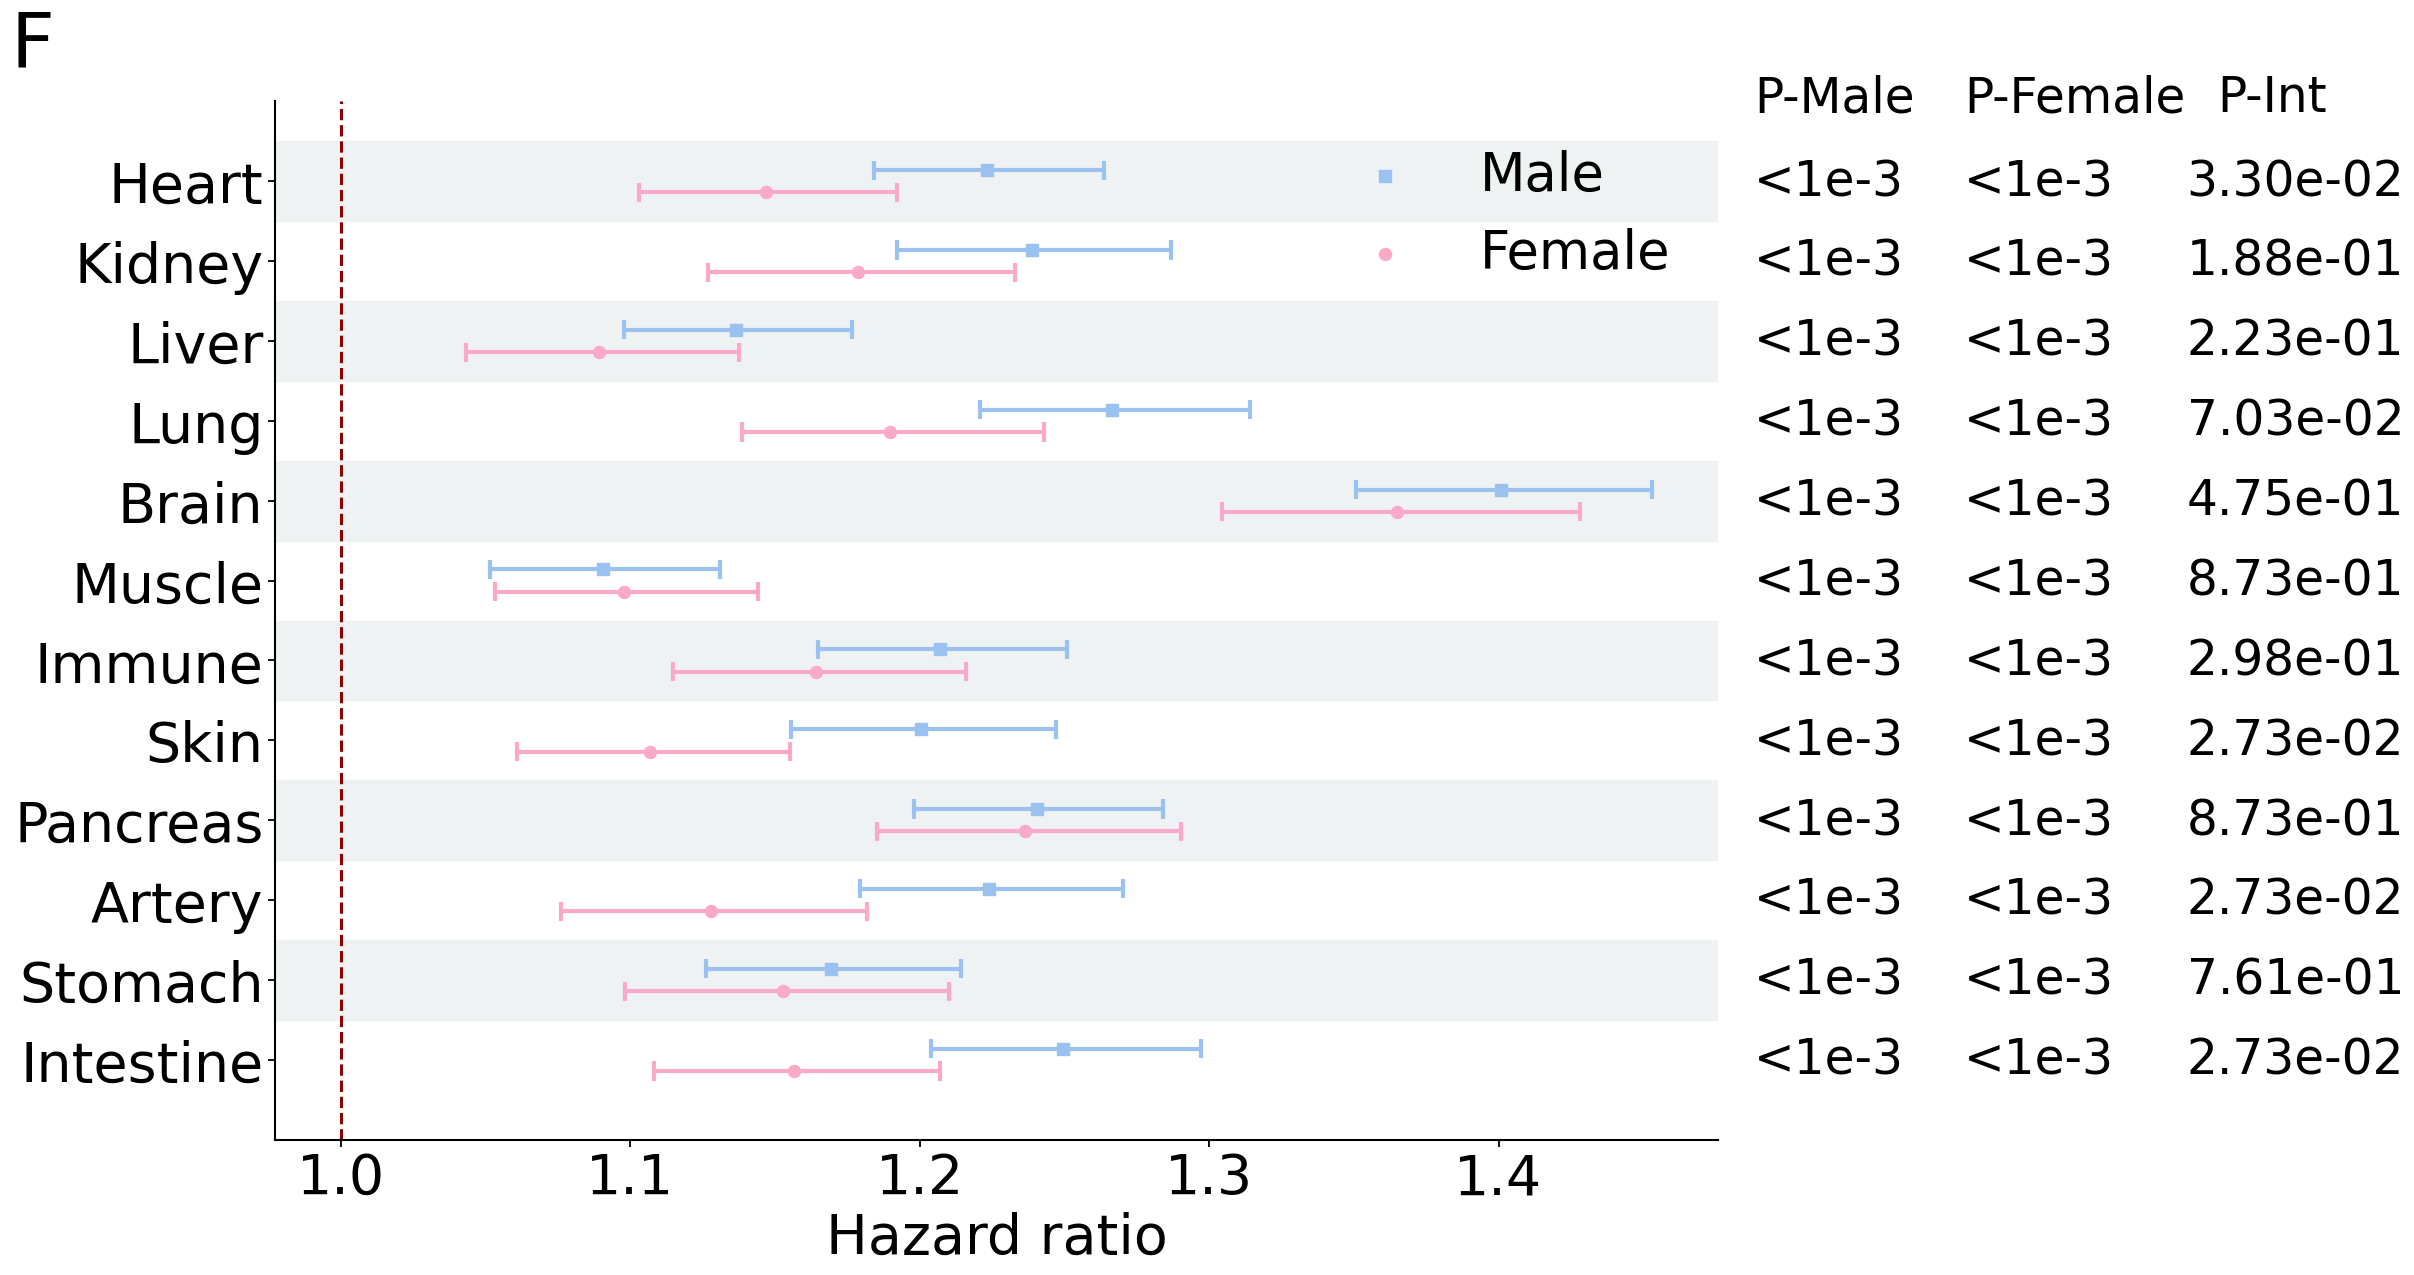

In [16]:
# Fig.3F


# =======================
# CONFIG
# =======================


ORGANS = [
    "Heart_Z_Gap", "Kidney_Z_Gap", "Liver_Z_Gap", "Lung_Z_Gap",
    "Brain_Z_Gap", "Muscle_Z_Gap", "Immune_Z_Gap", "Skin_Z_Gap",
    "Pancreas_Z_Gap", "Artery_Z_Gap", "Stomach_Z_Gap", "Intestine_Z_Gap"
          ]

COL_ORGAN = "Organ"
COL_MODEL = "Model"
COL_GROUP = "Group"
COL_HR    = "HR"
COL_LO    = "Lower"
COL_HI    = "Upper"
COL_P     = "P-value"
COL_PINT  = "P_interaction_adj"

MALE_COLOR = "#9ac1f0"
FEMALE_COLOR = "#faaac7"

FIG_W, FIG_H = 14.5, 8.0

POINT_SIZE = 75
CI_LW      = 3.0
CAP_LW     = 3.0
CAP_H      = 0.12

REF_LW     = 2.2
AXIS_LW    = 2.4
TICK_LEN   = 10
TICK_W     = 2.0

LABEL_FS   = 16
TITLE_FS   = 18
TEXT_FS    = 14
HEADER_FS  = 16

Y_OFF = 0.14

# =======================


def fmt_p(x):
    if pd.isna(x):
        return "NA"
    x = float(x)
    if x < 1e-3:
        return "<1e-3"
    return f"{x:.2e}"


def main():
    df = pd.read_csv(file_path_3F)
    df.columns = df.columns.str.strip()

    need = [COL_ORGAN, COL_GROUP, COL_HR, COL_LO, COL_HI, COL_P]
    miss = [c for c in need if c not in df.columns]
    if miss:
        raise ValueError(f"Missing columns: {miss}. Available: {list(df.columns)}")

    for c in [COL_HR, COL_LO, COL_HI, COL_P, COL_PINT]:
        if c in df.columns:
            df[c] = pd.to_numeric(df[c], errors="coerce")

    df[COL_GROUP] = df[COL_GROUP].astype(str).str.strip()
    df = df[df[COL_GROUP].isin(["Male", "Female"])].copy()

    pint_map = df.groupby(COL_ORGAN)[COL_PINT].apply(
        lambda s: s.dropna().iloc[0] if s.dropna().shape[0] > 0 else np.nan
    ).to_dict() if COL_PINT in df.columns else {}

    organs_exist = [o for o in ORGANS if o in set(df[COL_ORGAN])]
    if not organs_exist:
        raise ValueError("None of ORGANS found in CSV. Please check organ names in ORGANS vs CSV.")

    def get_one(organ, group, col):
        sub = df[(df[COL_ORGAN] == organ) & (df[COL_GROUP] == group)]
        if sub.empty:
            return np.nan
        return sub.iloc[0][col]

    n = len(organs_exist)
    y_base = np.arange(n)[::-1].astype(float)

    fig = plt.figure(figsize=(24, 12), constrained_layout=True)
    fig.text(0, 1.05, 'F', fontsize=55,
             verticalalignment='top', horizontalalignment='left',
             transform=fig.transFigure)

    gs = fig.add_gridspec(1, 2, width_ratios=[0.70, 0.30], wspace=0.02)

    ax = fig.add_subplot(gs[0, 0])
    axT = fig.add_subplot(gs[0, 1])
    axT.axis("off")

    for i in range(n):
        if i % 2 == 0:
            ax.axhspan(y_base[i] - 0.5, y_base[i] + 0.5, color="#eef2f2", zorder=0)

    ax.axvline(1.0, linestyle="--", linewidth=REF_LW, color="#8b0000")

    for i, organ in enumerate(organs_exist):
        y0 = y_base[i]

        hr_m = get_one(organ, "Male", COL_HR)
        lo_m = get_one(organ, "Male", COL_LO)
        hi_m = get_one(organ, "Male", COL_HI)

        hr_f = get_one(organ, "Female", COL_HR)
        lo_f = get_one(organ, "Female", COL_LO)
        hi_f = get_one(organ, "Female", COL_HI)

        if np.isfinite(hr_m) and np.isfinite(lo_m) and np.isfinite(hi_m):
            ym = y0 + Y_OFF
            ax.hlines(ym, lo_m, hi_m, linewidth=CI_LW, zorder=2,color=MALE_COLOR)
            ax.vlines(lo_m, ym - CAP_H, ym + CAP_H, linewidth=CAP_LW, zorder=2,color=MALE_COLOR)
            ax.vlines(hi_m, ym - CAP_H, ym + CAP_H, linewidth=CAP_LW, zorder=2,color=MALE_COLOR)
            ax.scatter(
                hr_m, ym,
                s=POINT_SIZE, marker="s",
                color=MALE_COLOR, edgecolor=MALE_COLOR,
                zorder=3, label="Male" if i == 0 else None
            )

        if np.isfinite(hr_f) and np.isfinite(lo_f) and np.isfinite(hi_f):
            yf = y0 - Y_OFF
            ax.hlines(yf, lo_f, hi_f, linewidth=CI_LW, zorder=2,color=FEMALE_COLOR)
            ax.vlines(lo_f, yf - CAP_H, yf + CAP_H, linewidth=CAP_LW, zorder=2,color=FEMALE_COLOR)
            ax.vlines(hi_f, yf - CAP_H, yf + CAP_H, linewidth=CAP_LW, zorder=2,color=FEMALE_COLOR)
            ax.scatter(
                hr_f, yf,
                s=POINT_SIZE, marker="o",
                color=FEMALE_COLOR, edgecolor=FEMALE_COLOR,
                zorder=3, label="Female" if i == 0 else None
            )

    ax.set_yticks(y_base)
    ax.set_yticklabels([o.replace("_Z_Gap", "") for o in organs_exist], fontsize=40)

    ax.set_xlabel("Hazard ratio", fontsize=40)

    ax.tick_params(axis="x", which="major", length=TICK_LEN, width=TICK_W, direction="out", labelsize=40)
    ax.tick_params(axis="y", which="major", length=TICK_LEN, width=TICK_W, direction="out")

    ax.spines["bottom"].set_linewidth(AXIS_LW)
    ax.spines["left"].set_linewidth(AXIS_LW)
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_ylim(-1, n)

    ax.legend(loc="upper right", fontsize=38, frameon=False)

    axT.set_ylim(ax.get_ylim())
    axT.set_xlim(0, 1)

    axT.text(0.02, n - 0.25, "P-Male", fontsize=35,  ha="left", va="bottom")
    axT.text(0.36, n - 0.25, "P-Female", fontsize=35,  ha="left", va="bottom")
    axT.text(0.77, n - 0.25, "P-Int", fontsize=35, ha="left", va="bottom")

    for i, organ in enumerate(organs_exist):
        y0 = y_base[i]

        p_m = get_one(organ, "Male", COL_P)
        p_f = get_one(organ, "Female", COL_P)
        p_i = pint_map.get(organ, np.nan)

        axT.text(0.02, y0, fmt_p(p_m), fontsize=35, ha="left", va="center")
        axT.text(0.36, y0, fmt_p(p_f), fontsize=35, ha="left", va="center")
        axT.text(0.72, y0, fmt_p(p_i), fontsize=35, ha="left", va="center")

        ax.tick_params(axis='both', which='major', labelsize=40)
        ax.tick_params(axis='both', which='major', width=1.3, length=5)
        for axis in ['bottom', 'left']:
            ax.spines[axis].set_linewidth(1.5)

    plt.show()



main()

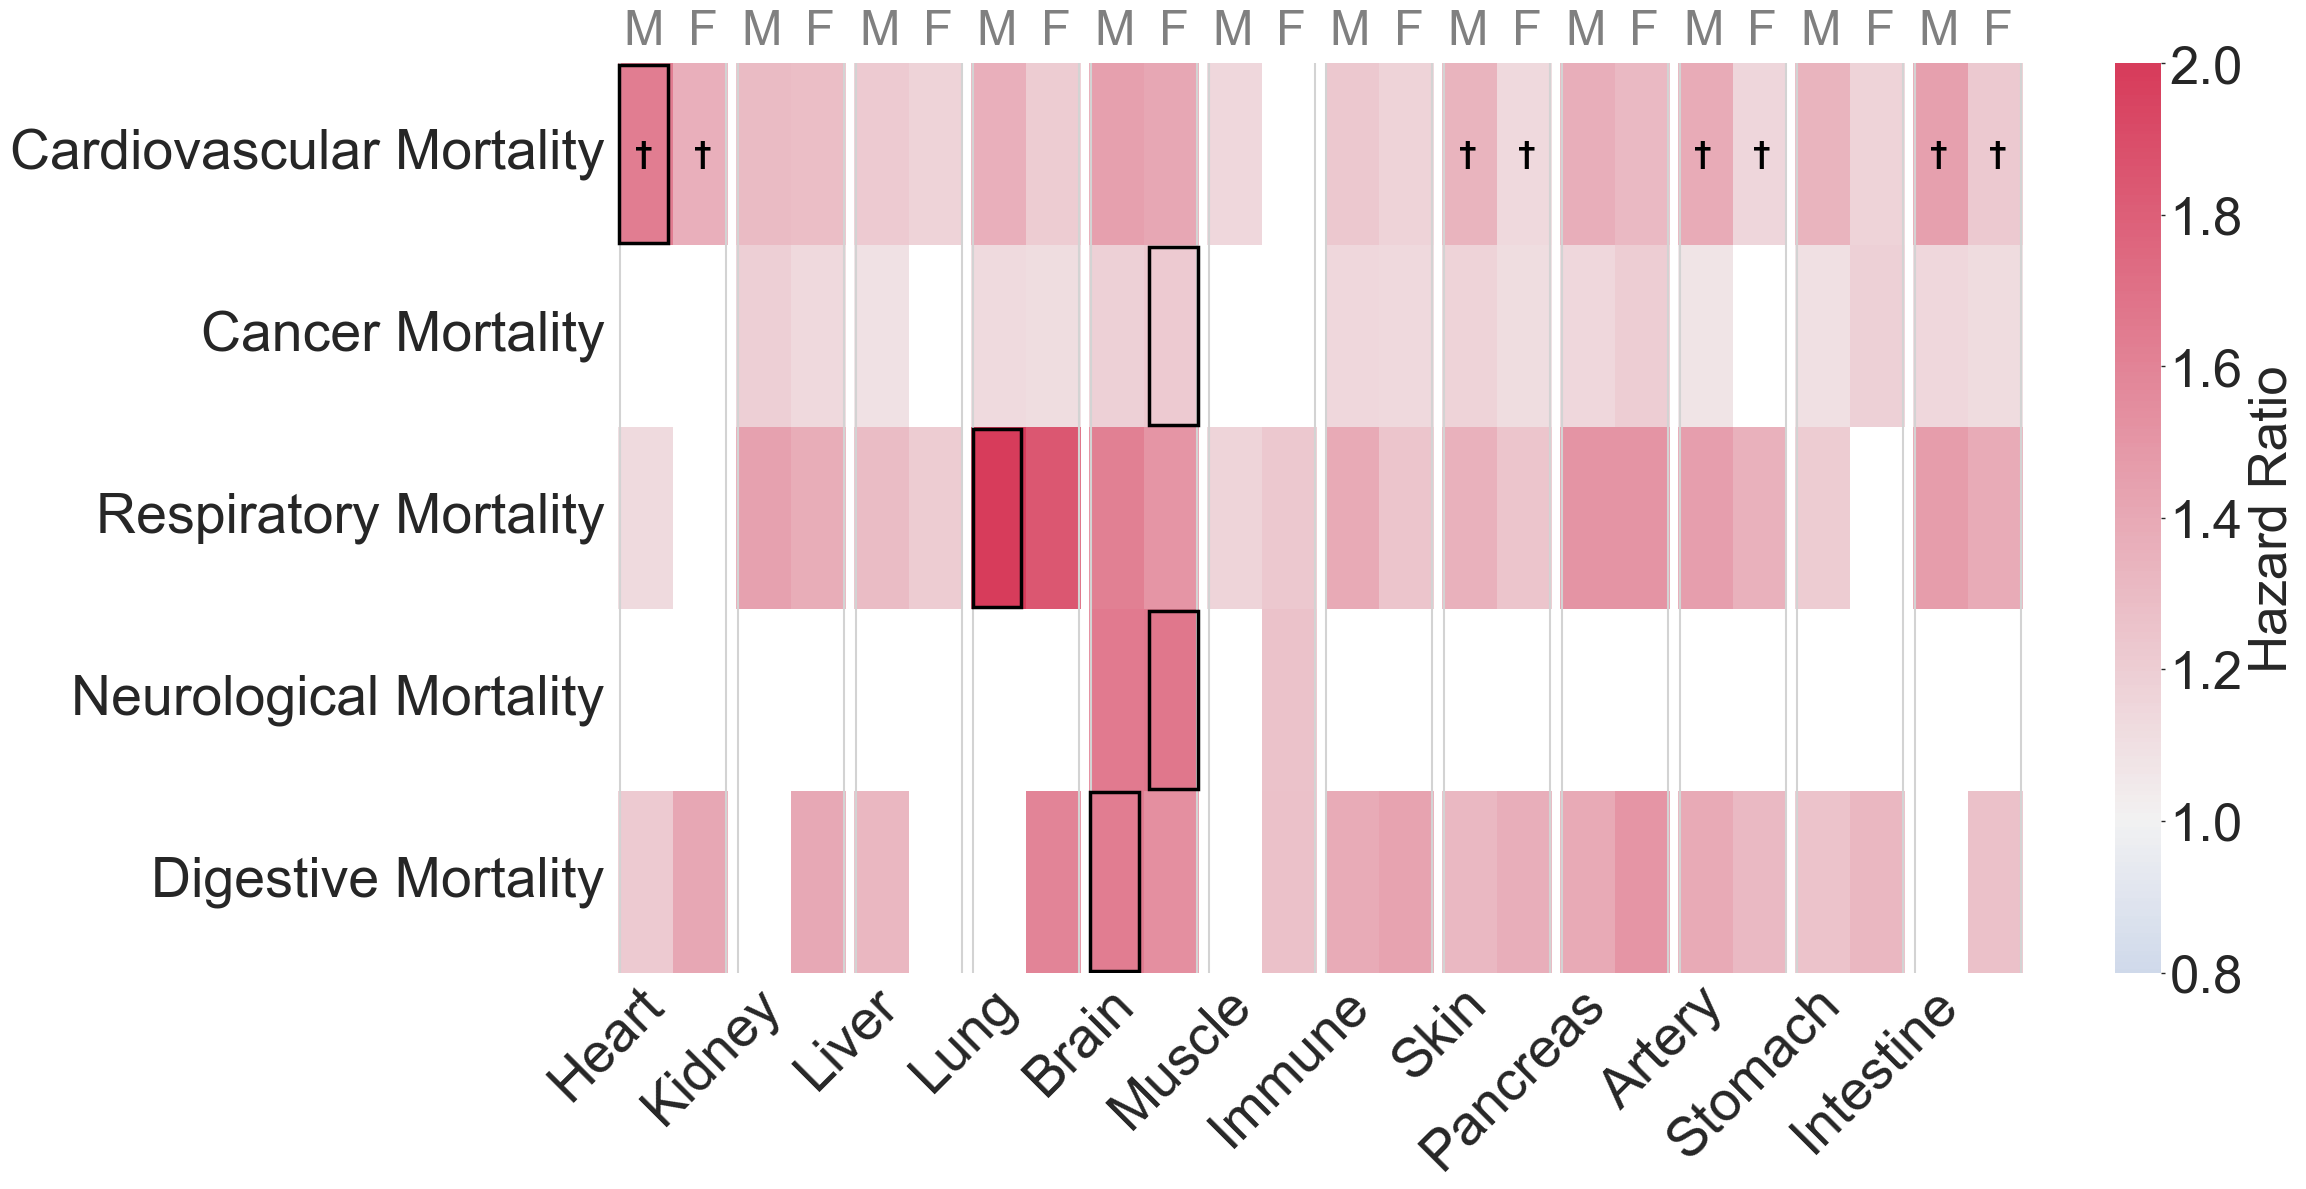

In [19]:
# Fig.3G



sns.set_style("white")

custom_cmap = sns.diverging_palette(255, 5, as_cmap=True)

ORGAN_ORDER = [
    "Heart_Z_Gap", "Kidney_Z_Gap", "Liver_Z_Gap", "Lung_Z_Gap",
    "Brain_Z_Gap", "Muscle_Z_Gap", "Immune_Z_Gap", "Skin_Z_Gap",
    "Pancreas_Z_Gap", "Artery_Z_Gap", "Stomach_Z_Gap", "Intestine_Z_Gap"
]

MORTALITY_ORDER = ['CVD', 'CANCER', 'RESP', 'NEURO', 'DIGES']

def clean_label(text):
    name_map = {
        'CVD': 'Cardiovascular',
        'CANCER': 'Cancer',
        'RESP': 'Respiratory',
        'NEURO': 'Neurological',
        'DIGES': 'Digestive'
    }
    base = name_map.get(text, text)
    return f"{base} Mortality"

def plot_mortality_heatmap_doublecol():
    df = pd.read_csv(file_path_3G)

    df_male = df[df['Group'] == 'Male'].set_index(['Mortality_Type', 'Predictor_Gap'])
    df_female = df[df['Group'] == 'Female'].set_index(['Mortality_Type', 'Predictor_Gap'])
    df_total = df[df['Group'] == 'Total'].set_index(['Mortality_Type', 'Predictor_Gap'])

    hr_male = df_male['HR'].unstack('Predictor_Gap').reindex(index=MORTALITY_ORDER, columns=ORGAN_ORDER)
    hr_female = df_female['HR'].unstack('Predictor_Gap').reindex(index=MORTALITY_ORDER, columns=ORGAN_ORDER)

    mask_male = (df_male['P_val_adj'].unstack('Predictor_Gap').reindex(index=MORTALITY_ORDER, columns=ORGAN_ORDER) >= 0.05)
    mask_female = (df_female['P_val_adj'].unstack('Predictor_Gap').reindex(index=MORTALITY_ORDER, columns=ORGAN_ORDER) >= 0.05)

    p_inter = df_total['P_interaction_fdr'].unstack('Predictor_Gap').reindex(index=MORTALITY_ORDER, columns=ORGAN_ORDER)

    hr_male_plot = hr_male.mask(mask_male, 0)
    hr_female_plot = hr_female.mask(mask_female, 0)

    mat_hr, mat_text = [], []
    highlight_coords = []

    for r_idx, mort in enumerate(MORTALITY_ORDER):
        row_hr, row_text = [], []
        candidates = []

        col_idx = 0
        for organ in ORGAN_ORDER:
            inter_sig = (pd.notna(p_inter.loc[mort, organ]) and p_inter.loc[mort, organ] < 0.05)
            mark = "†" if inter_sig else ""

            v_m = hr_male_plot.loc[mort, organ]
            row_hr.append(v_m)
            row_text.append(mark)
            if pd.notna(v_m) and v_m != 0:
                candidates.append((v_m, col_idx))
            col_idx += 1

            v_f = hr_female_plot.loc[mort, organ]
            row_hr.append(v_f)
            row_text.append(mark)
            if pd.notna(v_f) and v_f != 0:
                candidates.append((v_f, col_idx))
            col_idx += 1

        mat_hr.append(row_hr)
        mat_text.append(row_text)

        if candidates:
            candidates.sort(key=lambda x: x[0], reverse=True)
            max_v, max_c = candidates[0]
            if max_v > 0:
                highlight_coords.append((r_idx, max_c))

    df_hr = pd.DataFrame(mat_hr, index=MORTALITY_ORDER)
    df_text = pd.DataFrame(mat_text, index=MORTALITY_ORDER)

    col_names = []
    for organ in ORGAN_ORDER:
        col_names.extend([f"{organ}_M", f"{organ}_F"])
    df_hr.columns = col_names
    df_text.columns = col_names

    fig, ax = plt.subplots(figsize=(24, 12))


    v_min, v_max, center = 0.8, 2.0, 1.0
    mask0 = (df_hr == 0) | (df_hr.isna())

    sns.heatmap(
        df_hr,
        cmap=custom_cmap,
        center=center,
        vmin=v_min, vmax=v_max,
        mask=mask0,
        annot=df_text, fmt='',
        annot_kws={'size': 23, 'weight': 'bold', 'color': 'black'},
        linewidths=0,
        xticklabels=False,
        ax=ax
    )
    ax.set_xlim(0, df_hr.shape[1])
    ax.set_ylim(df_hr.shape[0], 0)
    cbar = ax.collections[0].colorbar
    cbar.set_label(label='Hazard Ratio', fontsize=38)
    cbar.ax.tick_params(labelsize=38, width=1.0, length=3)

    n_cols = df_hr.shape[1]
    for i in range(0, n_cols + 1, 2):
        ax.axvline(i, color='white', lw=6, clip_on=True, zorder=5)
        if i > 0:
            ax.axvline(i - 0.1, color='lightgrey', lw=1.5, clip_on=True, zorder=5)
        if i < n_cols:
            ax.axvline(i + 0.1, color='lightgrey', lw=1.5, clip_on=True, zorder=5)
            ax.text(i + 0.5, 1.01, 'M', ha='center', va='bottom',
                    transform=ax.get_xaxis_transform(), fontsize=35, color='gray')
            ax.text(i + 1.5, 1.01, 'F', ha='center', va='bottom',
                    transform=ax.get_xaxis_transform(), fontsize=35, color='gray')

    pad_y = 0.01
    pad_x_inner = 0.085
    pad_x_outer = 0.087

    for r, c in highlight_coords:
        is_male_col = (c % 2 == 0)

        if is_male_col:
            left_pad = pad_x_outer
            right_pad = pad_x_inner
        else:
            left_pad = pad_x_inner
            right_pad = pad_x_outer

        rect = patches.Rectangle(
            (c + left_pad, r + pad_y),
            1 - left_pad - right_pad,
            1 - 2 * pad_y,
            linewidth=2.5,
            edgecolor='black',
            facecolor='none',
            clip_on=True,
            zorder=100,
            joinstyle='miter'
        )
        ax.add_patch(rect)

    y_labels = [clean_label(m) for m in MORTALITY_ORDER]
    x_labels = [o.replace('_Z_Gap', '').title() for o in ORGAN_ORDER]

    ax.set_yticklabels(y_labels, rotation=0, fontsize=40)
    bottom_ticks = np.arange(len(ORGAN_ORDER)) * 2 + 1
    ax.set_xticks(bottom_ticks)
    ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=40)
    ax.tick_params(axis='x', length=0)

    for spine in ax.spines.values():
        spine.set_visible(False)

    plt.tight_layout()
    plt.show()


plot_mortality_heatmap_doublecol()